# Fake Speech Data Plots\n
\n
This notebook builds the visualizations from real recordings in `Sound_recordings/` and matching analysis outputs.

In [1]:
# Optional: install dependencies if missing (run once).
# Uncomment if needed:
# %pip install numpy matplotlib pandas ipywidgets librosa plotly

import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgb

from backend.pitch_detector import detect_pitch
from backend.speed import (
    calculate_wpm,
    count_words,
    extract_transcript_text as speed_extract_transcript_text,
    get_wav_duration_seconds,
 )
from main import SPEED_OUTPUT_DIR

PALETTE_HEX = ['#FF7979', '#21AFA2', '#1E8486', '#666563', '#327D79', '#27636D']
PRIMARY_TEAL = '#21AFA2'
DEEP_TEAL = '#1E8486'
SLATE = '#666563'
DARK_TEAL = '#27636D'
ACCENT_CORAL = '#FF7979'

HEATMAP_CMAP = LinearSegmentedColormap.from_list(
    'filler_teal_gradient',
    ['#F2FBFA', '#CFEDEA', '#8FD7D0', PRIMARY_TEAL, DEEP_TEAL, DARK_TEAL],
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13,
    'figure.titlesize': 19,
    'axes.prop_cycle': plt.cycler(color=PALETTE_HEX),
})

In [2]:
SOUND_DIR = Path('Sound_recordings')
TRANSCRIPTS_DIR = Path('Transcripts')
FILLER_DIR = Path('Filler_analysis')

# Keep compatibility with your pipeline naming from main.py
SPEED_DIR = SPEED_OUTPUT_DIR if 'SPEED_OUTPUT_DIR' in globals() else Path('Speed')

if not SOUND_DIR.exists():
    raise FileNotFoundError(f'Could not find folder: {SOUND_DIR}')
if not TRANSCRIPTS_DIR.exists():
    raise FileNotFoundError(f'Could not find folder: {TRANSCRIPTS_DIR}')
if not FILLER_DIR.exists():
    raise FileNotFoundError(f'Could not find folder: {FILLER_DIR}')
if not SPEED_DIR.exists():
    raise FileNotFoundError(f'Could not find folder: {SPEED_DIR}')

wav_files = sorted(SOUND_DIR.glob('*.wav'))
if not wav_files:
    raise FileNotFoundError(f'No .wav files found in: {SOUND_DIR}')

def parse_timestamp(name):
    match = re.search(r'(\d{8}_\d{6})', name)
    return match.group(1) if match else None

def load_json_if_exists(path):
    if path.exists():
        return json.loads(path.read_text(encoding='utf-8'))
    return {}

def resolve_transcript_path(recording_id, timestamp):
    if timestamp:
        candidate = TRANSCRIPTS_DIR / f'transcript_{timestamp}.txt'
        if candidate.exists():
            return candidate

    direct_match = TRANSCRIPTS_DIR / f'{recording_id}.txt'
    if direct_match.exists():
        return direct_match

    return None

def build_filler_events_from_counts(filler_counts, duration):
    words_expanded = []
    for word, count in sorted(filler_counts.items()):
        safe_count = max(0, int(count))
        words_expanded.extend([word] * safe_count)

    total = len(words_expanded)
    if total == 0:
        return []

    end_time = max(float(duration), 1.0)
    events = []
    for idx, word in enumerate(words_expanded):
        ratio = float((idx + 0.5) / total)
        t = float(ratio * end_time)
        events.append({
            'word': word,
            'position_ratio': ratio,
            'time': t,
        })

    return events

def build_filler_time_bins(events, filler_words, duration, bin_size=10.0):
    end_time = max(float(duration), bin_size)
    edges = np.arange(0.0, end_time + bin_size, bin_size)
    bins = []

    for start, end in zip(edges[:-1], edges[1:]):
        item = {'time_start': float(start), 'time_end': float(end), **{w: 0 for w in filler_words}}
        for event in events:
            t = event['time']
            if (start <= t < end) or (t == end_time and end == end_time):
                item[event['word']] = item.get(event['word'], 0) + 1
        item['total'] = int(sum(item[w] for w in filler_words))
        bins.append(item)

    return bins

def build_rolling_wpm(total_words, duration):
    if duration <= 0:
        return [{'time': 1.0, 'wpm': 0.0}]
    times = np.arange(1.0, max(2.0, np.floor(duration) + 1), 1.0)
    if total_words > 0:
        word_times = np.linspace(0.0, duration, total_words, endpoint=False)
    else:
        word_times = np.array([])

    series = []
    for t in times:
        start = max(0.0, t - 30.0)
        count = int(np.sum((word_times > start) & (word_times <= t)))
        series.append({'time': float(t), 'wpm': float(count * 2.0)})
    return series

recordings = []
filler_words_set = set()

for wav_path in wav_files:
    recording_id = wav_path.stem
    timestamp = parse_timestamp(recording_id)

    transcript_path = resolve_transcript_path(recording_id, timestamp)
    transcript_raw = transcript_path.read_text(encoding='utf-8', errors='ignore') if transcript_path else ''
    transcript_text = speed_extract_transcript_text(transcript_raw) if transcript_raw else ''

    # speed.py based metrics
    transcript_total_words = count_words(transcript_text) if transcript_text else 0
    duration_seconds = float(get_wav_duration_seconds(wav_path))
    overall_wpm = float(calculate_wpm(transcript_total_words, duration_seconds)) if transcript_total_words > 0 else 0.0

    # Read pipeline exports (source of truth for filler/speed)
    speed_json = load_json_if_exists(SPEED_DIR / f'speed_{timestamp}.json') if timestamp else {}
    filler_json = load_json_if_exists(FILLER_DIR / f'filler_analysis_{timestamp}.json') if timestamp else {}

    filler_counts_raw = filler_json.get('filler_word_counts', {}) if isinstance(filler_json, dict) else {}
    filler_counts = {
        str(word): int(count)
        for word, count in filler_counts_raw.items()
        if isinstance(word, str) and int(count) > 0
    }

    filler_words_set.update(filler_counts.keys())
    total_filler_words = int(filler_json.get('total_filler_words', sum(filler_counts.values())))

    # Build timeline features used by notebook plots (estimated from per-recording counts)
    events = build_filler_events_from_counts(filler_counts, duration_seconds)
    rolling_wpm = build_rolling_wpm(int(speed_json.get('total_words', transcript_total_words)), duration_seconds)

    # pitch_detector.py based metrics
    pitch_data = detect_pitch(
        wav_path,
        backend='librosa',
        trim_silence=True,
        trim_top_db=30,
        trim_unvoiced_edges=False,
    )
    pitch_track = [
        {
            'time': float(t),
            'pitch_hz': None if (not np.isfinite(f)) else float(f),
            'pitch_st': None if (not np.isfinite(st)) else float(st),
            'voiced': bool(v),
        }
        for t, f, st, v in zip(
            pitch_data['time'],
            pitch_data['frequency'],
            pitch_data['pitch_semitones'],
            pitch_data['voiced_flag'],
        )
    ]

    recordings.append({
        'recording_id': recording_id,
        'filler_events': events,
        'rolling_wpm_30s': rolling_wpm,
        'pitch_track': pitch_track,
        'pitch_summary': {
            'median_hz': float(pitch_data['median_pitch']),
            'min_hz': float(pitch_data['min_pitch']),
            'max_hz': float(pitch_data['max_pitch']),
            'mean_st': float(pitch_data['mean_pitch_semitones']),
            'min_st': float(pitch_data['min_pitch_semitones']),
            'max_st': float(pitch_data['max_pitch_semitones']),
            'median_st': float(pitch_data['median_pitch_semitones']),
            'reference_hz': float(pitch_data['pitch_reference_hz']),
            'voiced_ratio': float(pitch_data['voiced_ratio']),
        },
        'duration_seconds': duration_seconds,
        'total_words': int(speed_json.get('total_words', transcript_total_words)),
        'wpm': float(speed_json.get('wpm', overall_wpm)),
        'total_filler_words': total_filler_words,
        'filler_word_counts': filler_counts,
    })

# Use observed filler words from Filler_analysis; fallback keeps plots stable if all counts are 0
filler_words = sorted(filler_words_set) if filler_words_set else ['uh', 'um', 'like', 'you know']

for rec in recordings:
    rec['filler_time_bins'] = build_filler_time_bins(
        rec.get('filler_events', []),
        filler_words,
        rec.get('duration_seconds', 0.0),
    )

recording_ids = [r['recording_id'] for r in recordings]

all_filler_counts = Counter()
for rec in recordings:
    all_filler_counts.update(rec.get('filler_word_counts', {}))

# Ensure every filler axis label appears in summary, even if count is 0
for filler in filler_words:
    all_filler_counts.setdefault(filler, 0)

total_words_all = int(sum(rec.get('total_words', 0) for rec in recordings))
total_fillers_all = int(sum(all_filler_counts.values()))
overall_pct = round((100.0 * total_fillers_all / total_words_all), 3) if total_words_all else 0.0

data = {
    'recordings': recordings,
    'total_words': total_words_all,
    'total_filler_words': total_fillers_all,
    'overall_filler_percentage': overall_pct,
    'filler_word_summary': [
        {'word': w, 'count': int(all_filler_counts.get(w, 0))}
        for w in filler_words
    ],
}

print(f"Loaded {len(recordings)} recordings")
print('Data sources: Filler_analysis + Sound_recordings + Speed + Transcripts')
print(f"Filler vocabulary: {filler_words}")
print(f"Total words: {data['total_words']}")
print(f"Total fillers: {data['total_filler_words']} ({data['overall_filler_percentage']}%)")

Loading audio and detecting pitch (librosa)...
Loading audio and detecting pitch (librosa)...
Loading audio and detecting pitch (librosa)...
Loading audio and detecting pitch (librosa)...
Loading audio and detecting pitch (librosa)...
Loaded 5 recordings
Data sources: Filler_analysis + Sound_recordings + Speed + Transcripts
Filler vocabulary: ["i don't know", 'i guess', 'kind of', 'like', 'so', 'um', "what's it called", 'yeah']
Total words: 379
Total fillers: 26 (6.86%)


## 1) Filler counts by recording

This replaces the synthetic position-density view with a clearer count-based chart that shows how many fillers appear in each recording, broken down by filler word.

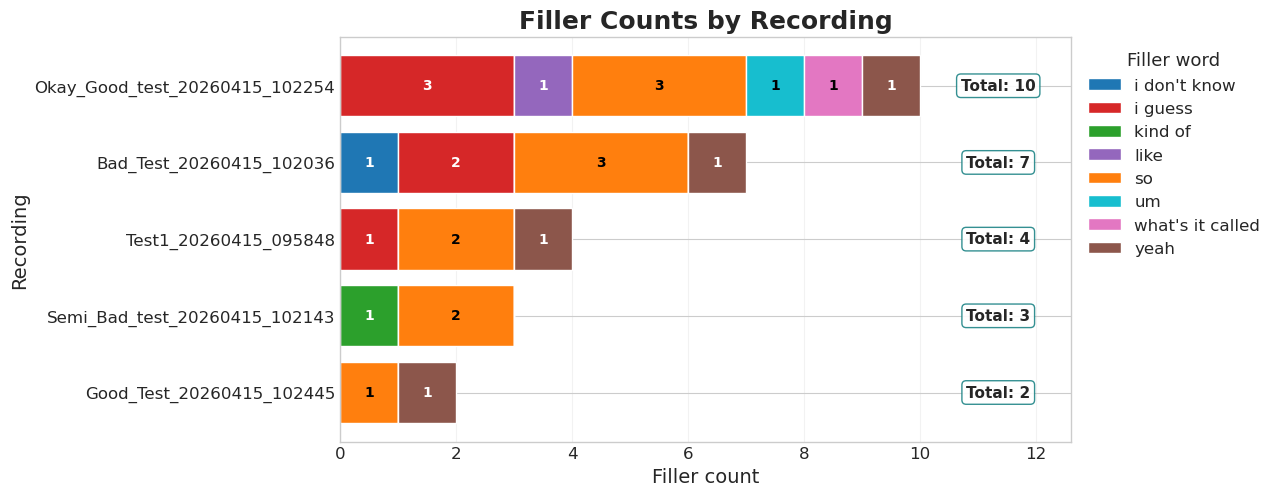

In [4]:
recording_totals = [sum(rec.get('filler_word_counts', {}).values()) for rec in recordings]
recording_order = sorted(range(len(recordings)), key=lambda i: recording_totals[i], reverse=True)
ordered_recordings = [recordings[i] for i in recording_order]
ordered_ids = [rec['recording_id'] for rec in ordered_recordings]
ordered_totals = [sum(rec.get('filler_word_counts', {}).values()) for rec in ordered_recordings]
y_positions = np.arange(len(ordered_recordings))

fig, ax = plt.subplots(figsize=(12.4, max(4.2, 0.65 * len(ordered_recordings) + 1.6)), constrained_layout=True)

left = np.zeros(len(ordered_recordings), dtype=float)

# High-contrast categorical palette for maximum separation between filler words.
distinct_colors = [
    '#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e',
    '#17becf', '#e377c2', '#8c564b', '#bcbd22', '#7f7f7f',
]
colors = [distinct_colors[i % len(distinct_colors)] for i in range(max(1, len(filler_words)))]

for idx, word in enumerate(filler_words):
    values = np.array([rec.get('filler_word_counts', {}).get(word, 0) for rec in ordered_recordings], dtype=float)
    bars = ax.barh(y_positions, values, left=left, color=colors[idx], label=word, edgecolor='white', linewidth=1.0)

    # Add per-filler counts centered in each non-zero segment.
    r, g, b = to_rgb(colors[idx])
    luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
    text_color = 'white' if luminance < 0.5 else 'black'
    for bar, value in zip(bars, values):
        if value > 0:
            x = bar.get_x() + bar.get_width() / 2.0
            y = bar.get_y() + bar.get_height() / 2.0
            ax.text(x, y, f'{int(value)}', ha='center', va='center', fontsize=10, color=text_color, fontweight='bold')

    left += values

max_total = max(ordered_totals) if ordered_totals else 0
right_pad = max(1.2, 0.26 * max_total) if max_total > 0 else 1.2
ax.set_xlim(0, max_total + right_pad)

# Add total counts in a dedicated right-side lane inside the plot area.
for y_pos, total in zip(y_positions, ordered_totals):
    ax.text(
        max_total + 0.52 * right_pad,
        y_pos,
        f'Total: {int(total)}',
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        bbox={'boxstyle': 'round,pad=0.28', 'facecolor': 'white', 'edgecolor': DEEP_TEAL, 'alpha': 0.9},
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(ordered_ids)
ax.set_xlabel('Filler count')
ax.set_ylabel('Recording')
ax.set_title('Filler Counts by Recording')
ax.invert_yaxis()
ax.legend(title='Filler word', loc='upper right', bbox_to_anchor=(1.28, 1.0), frameon=False)
ax.grid(axis='x', alpha=0.25)

plt.show()

## 2) Filler words over time (line plot)

Equivalent to Social Data Story-style plot: x=time, y=count, one line per filler word.

In [7]:
from matplotlib.animation import FuncAnimation
from matplotlib.ticker import MaxNLocator
from IPython.display import HTML
import matplotlib.pyplot as plt

selected_id = recording_ids[0]  # Change this to another recording_id
rec = next(r for r in recordings if r['recording_id'] == selected_id)
bins = rec['filler_time_bins']
times = [(b['time_start'] + b['time_end']) / 2 for b in bins]

# Create figure and axis
fig, ax = plt.subplots(figsize=(12.6, 5.2))
fig.subplots_adjust(right=0.77)

# Prepare data for all filler words
filler_data = {w: [b.get(w, 0) for b in bins] for w in filler_words}
total_data = [b.get('total', 0) for b in bins]

# Use the same distinct mapping as plot 1.
distinct_colors = [
    '#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e',
    '#17becf', '#e377c2', '#8c564b', '#bcbd22', '#7f7f7f',
]
word_colors = {w: distinct_colors[i % len(distinct_colors)] for i, w in enumerate(filler_words)}

# Set up robust plot limits for both one-recording and many-recording cases
x_min = min(times) - 1 if times else 0
x_max = max(times) + 1 if times else 1
ax.set_xlim(x_min, x_max)

max_series_value = 0
if filler_data:
    max_series_value = max(max(values) for values in filler_data.values())
if total_data:
    max_series_value = max(max_series_value, max(total_data))
y_max = max(1.0, max_series_value * 1.1)
ax.set_ylim(0, y_max)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Filler count per bin')
ax.set_title(f"Filler Words Over Time - {selected_id}", pad=16)
ax.text(
    0.5,
    1.01,
    'Count per bin = number of times a filler word appears within each time interval (bin).',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=11,
    color=SLATE,
)

# Store line objects
lines = {}
for w in filler_words:
    line, = ax.plot([], [], marker='o', linewidth=2.2, label=w, color=word_colors[w])
    lines[w] = line

total_line, = ax.plot([], [], color=DARK_TEAL, linewidth=2.8, linestyle='--', label='total')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0.0, frameon=False)

# Animation function
def animate(frame):
    # frame goes from 0 to len(times)
    for w in filler_words:
        lines[w].set_data(times[:frame+1], filler_data[w][:frame+1])
    total_line.set_data(times[:frame+1], total_data[:frame+1])
    return list(lines.values()) + [total_line]

# Create animation
anim = FuncAnimation(fig, animate, frames=max(1, len(times)), interval=200, blit=True, repeat=True)

# Display the animation
plt.close(fig)
HTML(anim.to_jshtml())

## 3) Pace over time (rolling 30-second WPM)

Rolling 30-second WPM means the speaking rate is calculated using a moving 30-second window across the recording. At each time point, words spoken in the most recent 30 seconds are converted to words per minute, which helps smooth short-term noise while still showing pace changes over time.

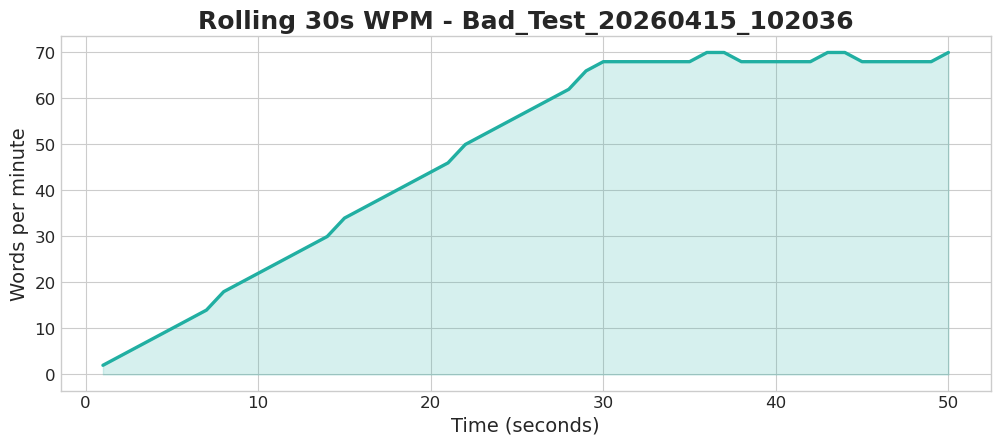

In [8]:
selected_id = recording_ids[0]  # Change as needed
rec = next(r for r in recordings if r['recording_id'] == selected_id)
rw = rec['rolling_wpm_30s']
times = [p['time'] for p in rw]
wpm = [p['wpm'] for p in rw]

plt.figure(figsize=(12, 4.6))
plt.plot(times, wpm, color=PRIMARY_TEAL, linewidth=2.4)
plt.fill_between(times, wpm, alpha=0.18, color=PRIMARY_TEAL)
plt.title(f"Rolling 30s WPM - {selected_id}")
plt.xlabel('Time (seconds)')
plt.ylabel('Words per minute')
plt.show()

## 4) Heatmap showing filler words across recordings

This view shows how often each filler word appears in each recording. Rows are sorted by overall frequency so the densest words stand out first.

In [9]:
# Generate filler word summary for the heatmap
summary = data['filler_word_summary']
summary_map = {item['word']: item for item in summary}

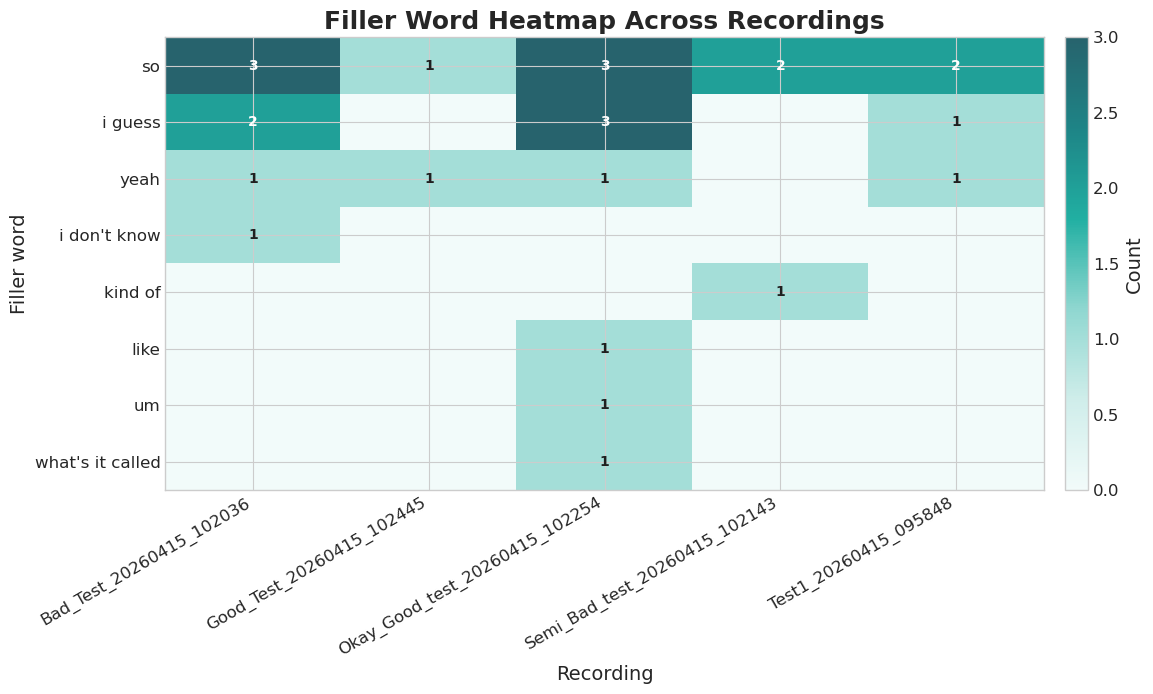

In [10]:
filler_order = sorted(summary_map.keys(), key=lambda w: summary_map[w]['count'], reverse=True)
heatmap = np.array(
    [
        [sum(1 for event in rec.get('filler_events', []) if event['word'] == word) for rec in recordings]
        for word in filler_order
    ],
    dtype=float,
)

fig, ax = plt.subplots(figsize=(12.5, max(3.8, 0.7 * len(filler_order) + 1.5)))
im = ax.imshow(heatmap, cmap=HEATMAP_CMAP, aspect='auto')

ax.set_xticks(np.arange(len(recording_ids)))
ax.set_xticklabels(recording_ids, rotation=30, ha='right')
ax.set_yticks(np.arange(len(filler_order)))
ax.set_yticklabels(filler_order)
ax.set_xlabel('Recording')
ax.set_ylabel('Filler word')
ax.set_title('Filler Word Heatmap Across Recordings')

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Count')

max_count = heatmap.max() if heatmap.size else 0
for row_idx in range(heatmap.shape[0]):
    for col_idx in range(heatmap.shape[1]):
        count = int(heatmap[row_idx, col_idx])
        if count:
            text_color = 'white' if (max_count > 0 and count > 0.5 * max_count) else '#1f1f1f'
            ax.text(
                col_idx,
                row_idx,
                str(count),
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold',
                color=text_color,
            )

ax.set_xlim(-0.5, len(recording_ids) - 0.5)
ax.set_ylim(len(filler_order) - 0.5, -0.5)
plt.tight_layout()
plt.show()

## 5) Pitch variation plots

These pitch plots are based directly on output from `backend/pitch_detector.py` (`detect_pitch`):

1. Smoothed semitone contour for one recording (within-recording trend).
2. Median + range across recordings (between-recording comparison).

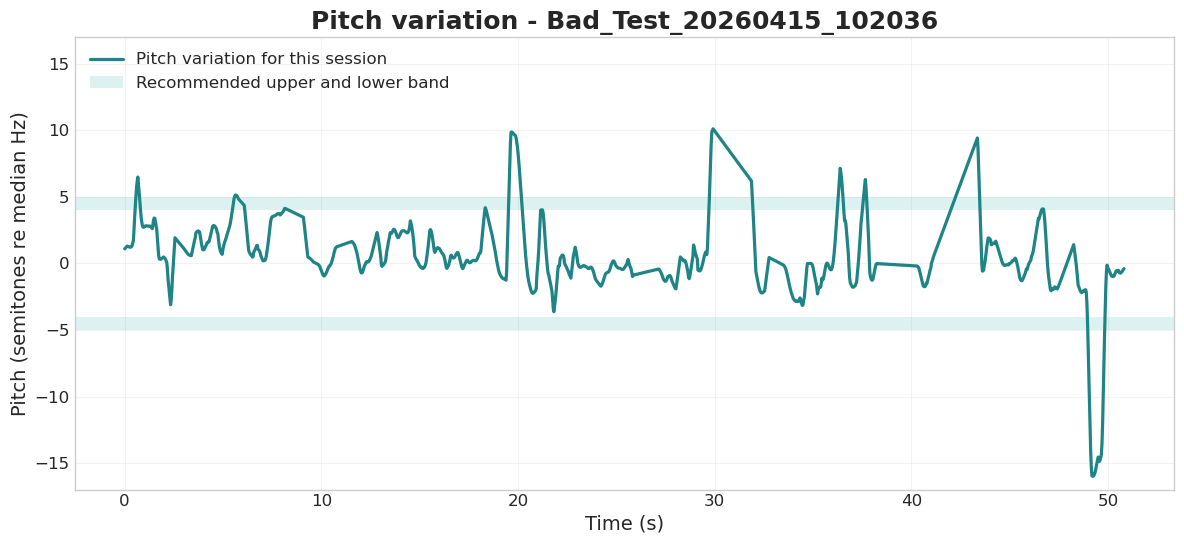

No previous recordings available for weighted average.
Pitch reference for selected recording: 205.11 Hz
Voiced ratio for selected recording: 64.2%


In [11]:
selected_id = recording_ids[0]  # Change as needed
rec = next(r for r in recordings if r['recording_id'] == selected_id)
track = rec['pitch_track']

times = np.array([p['time'] for p in track], dtype=float)
pitch_st = np.array([np.nan if p.get('pitch_st') is None else p.get('pitch_st') for p in track], dtype=float)
valid_st = np.isfinite(pitch_st)
if valid_st.sum() == 0:
    raise ValueError('No voiced pitch values in selected recording.')

# Build a continuous contour by interpolating across unvoiced gaps.
frame_idx = np.arange(len(pitch_st), dtype=float)
voiced_idx = frame_idx[valid_st]
continuous = np.interp(frame_idx, voiced_idx, pitch_st[valid_st])

# Smooth the contour for readability.
window = 7
if window % 2 == 0:
    window += 1
kernel = np.ones(window, dtype=float) / window
pad = window // 2
smoothed = np.convolve(np.pad(continuous, (pad, pad), mode='edge'), kernel, mode='valid')

def recording_variation(rec_item):
    t = rec_item.get('pitch_track', [])
    if not t:
        return np.nan

    st = np.array([np.nan if p.get('pitch_st') is None else p.get('pitch_st') for p in t], dtype=float)
    valid = np.isfinite(st)
    if valid.sum() >= 3:
        # Robust variation score: half of the 10th-90th percentile span.
        p10, p90 = np.nanpercentile(st[valid], [10, 90])
        return float((p90 - p10) / 2.0)

    # Fallback to detector summary if the track is too sparse for percentiles.
    summary = rec_item.get('pitch_summary', {})
    min_st = summary.get('min_st')
    max_st = summary.get('max_st')
    if min_st is not None and max_st is not None:
        return float((max_st - min_st) / 2.0)

    return np.nan

# Order is defined by notebook data order (recording_ids / recordings).
selected_pos = recording_ids.index(selected_id) if selected_id in recording_ids else None

# Weighted previous average variation: newer recordings count more.
previous_weighted_avg = None
if selected_pos is not None and selected_pos > 0:
    previous_recs = recordings[:selected_pos]
    previous_vals = [recording_variation(r) for r in previous_recs]
    previous_vals = [v for v in previous_vals if np.isfinite(v)]
    if previous_vals:
        decay = 0.65
        n = len(previous_vals)
        # Newer previous recordings get larger weights.
        weights = np.array([decay ** (n - 1 - i) for i in range(n)], dtype=float)
        previous_weighted_avg = float(np.sum(np.array(previous_vals) * weights) / np.sum(weights))

fig, ax = plt.subplots(figsize=(12, 5.6))
line_color = DEEP_TEAL
ax.plot(times, smoothed, color=line_color, linewidth=2.3, label='Pitch variation for this session')

# Recommended bands: +4 to +5 and -5 to -4 semitones.
ax.axhspan(4.0, 5.0, facecolor=PRIMARY_TEAL, alpha=0.16, edgecolor='none')
ax.axhspan(-5.0, -4.0, facecolor=PRIMARY_TEAL, alpha=0.16, edgecolor='none', label='Recommended upper and lower band')

if previous_weighted_avg is not None:
    ax.axhline(previous_weighted_avg, color=SLATE, linestyle=(0, (5, 4)), linewidth=1.5)
    ax.axhline(-previous_weighted_avg, color=SLATE, linestyle=(0, (5, 4)), linewidth=1.5, label=f'Previous average pitch variation ({previous_weighted_avg:.2f} st)')

ymax = max(10.0, np.nanmax(np.abs(smoothed)) + 1.0)
if previous_weighted_avg is not None:
    ymax = max(ymax, previous_weighted_avg + 1.0)
ax.set_ylim(-ymax, ymax)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Pitch (semitones re median Hz)')
ax.set_title(f'Pitch variation - {selected_id}')
ax.grid(True, alpha=0.25)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

if previous_weighted_avg is not None:
    print(f'Previous weighted average variation: {previous_weighted_avg:.2f} semitones')
else:
    print('No previous recordings available for weighted average.')

print(f"Pitch reference for selected recording: {rec['pitch_summary']['reference_hz']:.2f} Hz")
print(f"Voiced ratio for selected recording: {100.0 * rec['pitch_summary']['voiced_ratio']:.1f}%")

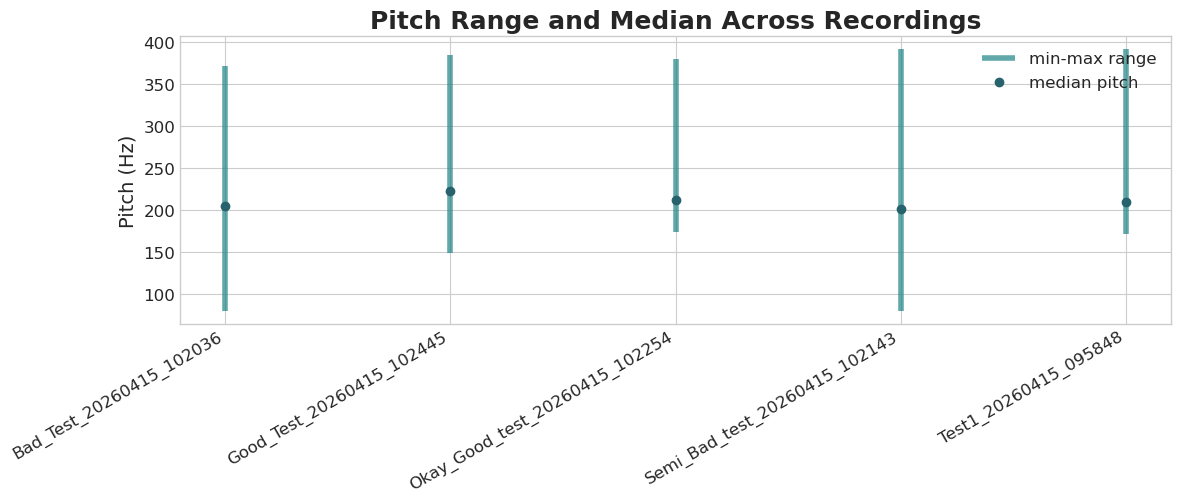

In [12]:
ids = [r['recording_id'] for r in recordings]
medians = [r['pitch_summary']['median_hz'] for r in recordings]
mins = [r['pitch_summary']['min_hz'] for r in recordings]
maxs = [r['pitch_summary']['max_hz'] for r in recordings]

x = np.arange(len(ids))
plt.figure(figsize=(12, 5.2))
plt.vlines(x, mins, maxs, color=DEEP_TEAL, alpha=0.7, linewidth=4, label='min-max range')
plt.scatter(x, medians, color=DARK_TEAL, zorder=3, label='median pitch')
plt.xticks(x, ids, rotation=30, ha='right')
plt.ylabel('Pitch (Hz)')
plt.title('Pitch Range and Median Across Recordings')
plt.legend()
plt.tight_layout()
plt.show()

## Optional next steps\n
- Change `selected_id` in the relevant cells to inspect another recording.\n
- Add more .wav files to `Sound_recordings/` and rerun the data-loading cell.\n
- Add export cells (`plt.savefig(...)`) for static report figures.

## 6) Filler count vs speaking pace

This scatter plot shows whether faster speaking correlates with more filler words, which could indicate nervousness or difficulty keeping up with thoughts.

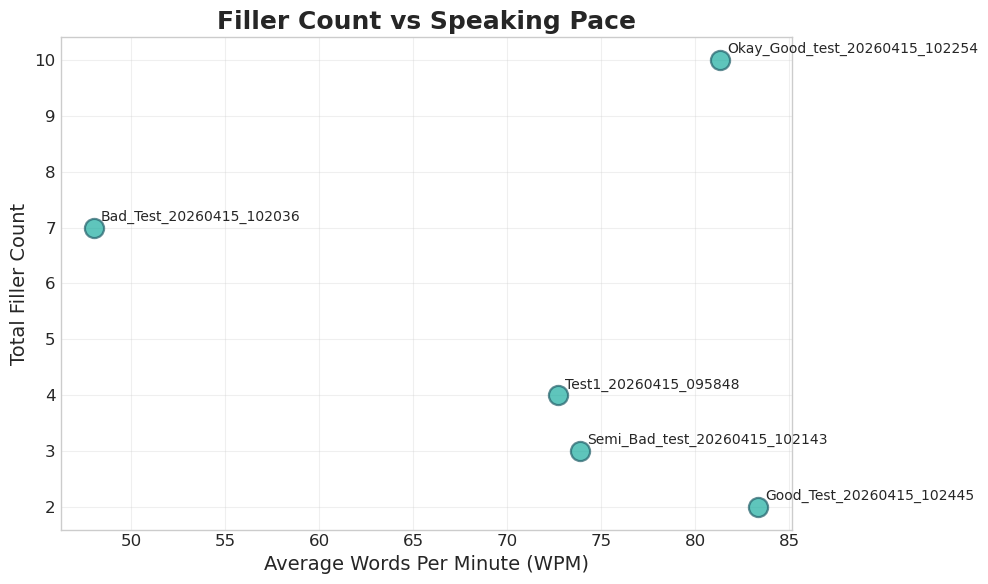

Correlation between WPM and filler count: -0.216


In [13]:
# Collect filler counts and average WPM for each recording
filler_counts = []
avg_wpm_values = []
rec_labels = []

for rec in recordings:
    total_fillers = len(rec.get('filler_events', []))
    filler_counts.append(total_fillers)
    
    # Calculate average WPM from rolling data
    rolling_wpm = rec.get('rolling_wpm_30s', [])
    if rolling_wpm:
        avg_wpm = np.mean([p['wpm'] for p in rolling_wpm])
    else:
        avg_wpm = 0
    avg_wpm_values.append(avg_wpm)
    rec_labels.append(rec['recording_id'])

plt.figure(figsize=(10, 6))
plt.scatter(avg_wpm_values, filler_counts, s=190, alpha=0.72, color=PRIMARY_TEAL, edgecolors=DARK_TEAL, linewidth=1.6)

# Add labels to each point
for i, label in enumerate(rec_labels):
    plt.annotate(label, (avg_wpm_values[i], filler_counts[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=10)

plt.xlabel('Average Words Per Minute (WPM)')
plt.ylabel('Total Filler Count')
plt.title('Filler Count vs Speaking Pace')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation if there are enough points
if len(filler_counts) > 2:
    correlation = np.corrcoef(avg_wpm_values, filler_counts)[0, 1]
    print(f"Correlation between WPM and filler count: {correlation:.3f}")

## 7) Filler words over time (interactive trend)

This plot uses each recording timestamp (date + time) and aggregates filler usage over calendar month or year.

- X-axis: month or year
- Y-axis: count of filler occurrences
- One line per filler word
- Click legend entries to toggle lines
- Hover each point for detailed values and contributing recordings

In [15]:
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
from datetime import datetime
from collections import defaultdict


def _recording_timestamp(rec):
    ts = parse_timestamp(rec.get('recording_id', ''))
    if not ts:
        return None
    try:
        return datetime.strptime(ts, '%Y%m%d_%H%M%S')
    except ValueError:
        return None


def _format_recording_list(recording_ids_in_period, items_per_line=2):
    ids_sorted = sorted(recording_ids_in_period)
    if not ids_sorted:
        return 'None'

    lines = []
    for i in range(0, len(ids_sorted), items_per_line):
        lines.append(', '.join(ids_sorted[i:i + items_per_line]))
    return '<br>'.join(lines)


trend_rows = []
for rec in recordings:
    dt = _recording_timestamp(rec)
    if dt is None:
        continue

    counts = rec.get('filler_word_counts', {})
    for word in filler_words:
        trend_rows.append(
            {
                'recording_id': rec.get('recording_id', 'unknown'),
                'timestamp': dt,
                'word': word,
                'count': int(counts.get(word, 0)),
            }
        )

if not trend_rows:
    print('No timestamped recordings found. Ensure recording IDs include YYYYMMDD_HHMMSS.')
else:
    granularity_dropdown = widgets.Dropdown(
        options=[('Monthly', 'month'), ('Yearly', 'year')],
        value='month',
        description='Group by:',
        layout=widgets.Layout(width='260px'),
    )

    title_html = widgets.HTML()

    # Use the exact same filler-word color mapping as plot 1 and plot 2.
    distinct_colors = [
        '#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e',
        '#17becf', '#e377c2', '#8c564b', '#bcbd22', '#7f7f7f',
    ]
    word_colors = {w: distinct_colors[i % len(distinct_colors)] for i, w in enumerate(filler_words)}

    def _period_key(dt, granularity):
        if granularity == 'year':
            return datetime(dt.year, 1, 1)
        return datetime(dt.year, dt.month, 1)

    def _build_plot(granularity):
        grouped = defaultdict(lambda: {'count': 0, 'recordings': set()})
        for row in trend_rows:
            key = (_period_key(row['timestamp'], granularity), row['word'])
            grouped[key]['count'] += row['count']
            grouped[key]['recordings'].add(row['recording_id'])

        periods_sorted = sorted({k[0] for k in grouped.keys()})
        x_label = 'Month' if granularity == 'month' else 'Year'
        tick_fmt = '%Y-%m' if granularity == 'month' else '%Y'

        fig = go.Figure()
        for word in filler_words:
            xs = periods_sorted
            ys = [grouped[(p, word)]['count'] if (p, word) in grouped else 0 for p in xs]
            rec_counts = [len(grouped[(p, word)]['recordings']) if (p, word) in grouped else 0 for p in xs]
            rec_lists = [
                _format_recording_list(grouped[(p, word)]['recordings']) if (p, word) in grouped else 'None'
                for p in xs
            ]
            line_color = word_colors[word]

            fig.add_trace(
                go.Scatter(
                    x=xs,
                    y=ys,
                    mode='lines+markers',
                    marker={'size': 8, 'color': line_color},
                    line={'width': 3, 'color': line_color},
                    name=word,
                    customdata=list(zip(rec_counts, rec_lists)),
                    hovertemplate=(
                        '<b>%{fullData.name}</b><br>'
                        + f'{x_label}: %{{x|{tick_fmt}}}<br>'
                        + 'Count: %{y}<br>'
                        + 'Appears in %{customdata[0]} recording(s)<br>'
                        + '<b>Recordings</b><br>%{customdata[1]}'
                        + '<extra></extra>'
                    ),
                )
            )

        start_ts = min(r['timestamp'] for r in trend_rows)
        end_ts = max(r['timestamp'] for r in trend_rows)
        fig.update_layout(
            title=f'Filler Word Usage Over Time ({granularity.title()})',
            xaxis_title=x_label,
            yaxis_title='Filler count',
            template='plotly_white',
            font={'family': 'DejaVu Sans', 'size': 16, 'color': '#1f2937'},
            title_font={'size': 30},
            hovermode='closest',
            legend_title='Filler word',
            legend={'font': {'size': 16}, 'title': {'font': {'size': 18}}},
            height=620,
            margin={'l': 90, 'r': 80, 't': 100, 'b': 90},
            hoverlabel={
                'bgcolor': 'rgba(245, 252, 251, 0.98)',
                'bordercolor': DEEP_TEAL,
                'font': {'size': 16, 'family': 'DejaVu Sans', 'color': '#102a2d'},
                'align': 'left',
                'namelength': -1,
            },
            paper_bgcolor='white',
            plot_bgcolor='white',
        )

        fig.update_xaxes(tickformat=tick_fmt, showgrid=True, gridcolor='rgba(39, 99, 109, 0.14)')
        fig.update_yaxes(showgrid=True, gridcolor='rgba(39, 99, 109, 0.14)')

        title_html.value = (
            f'<b style="font-family: DejaVu Sans; font-size: 15px; color: #1f2937;">Date range:</b> '
            f'<span style="font-family: DejaVu Sans; font-size: 15px; color: #1f2937;">{start_ts.strftime("%Y-%m-%d %H:%M:%S")} '
            f'to {end_ts.strftime("%Y-%m-%d %H:%M:%S")}</span>'
        )
        fig.show()

    out = widgets.interactive_output(_build_plot, {'granularity': granularity_dropdown})
    display(widgets.VBox([title_html, granularity_dropdown, out]))